# Project 3 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You will be allocated one of the three themes for part 2 - check announcements on canvas to see which theme is allocated to your group.

You will be working with the Cats and Dogs data set and/or the MNIST data set.

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke". 

The most structured way to do this is Nested CV. That is, an outer K-fold split into training and test and an inner CV-loop for tuning models. However, you can also use repeated random splits into training and testing instead of CV. The benefit of using CV is that the correlation between the outer splits, but a large number of random splits might be more beneficial if you want to compare many models in an outer loop. 


In [ ]:
import torch 
def get_device():
    """Select device where to perform the computations."""
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Selected device: {device}")

OSError: [WinError 1114] Initieringen av en DLL-fil misslyckades. Error loading "C:\Users\wwide\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [6]:
# First the cats and dogs data...
import pandas as pd 

PATHIM = "C://Users//wwide//MVE441//cnd_large//images.csv"
PATHLB = "C://Users//wwide//MVE441//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


In [7]:

import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

X = images
y = labels

# 1. Anta att dina bilder egentligen är 64x64 pixlar. 
# Vi omformar (reshape) datan från utplattad till 2D-bilder.
X_images = X.reshape(-1, 64, 64)

# 2. Beskär bilderna (ta bort 5 pixlar från topp, botten, vänster, höger)
# [:, 5:-5, 5:-5] betyder: behåll alla bilder, men klipp kanterna på höjd och bredd
X_cropped = X_images[:, 6:-6, 6:-6]

# Se de nya dimensionerna på en enskild bild
print("Gamla mått:", (64, 64))
print("Nya mått:", X_cropped.shape[1:]) 

# 3. Platta till bilderna igen till en lång rad (så att GridSearch förstår datan)
X_final = X_cropped.reshape(X_cropped.shape[0], -1)

print("Nytt antal kolumner (features) per bild:", X_final.shape[1])

Gamla mått: (64, 64)
Nya mått: (52, 52)
Nytt antal kolumner (features) per bild: 2704


ValueError: cannot reshape array of size 2704 into shape (64,64)

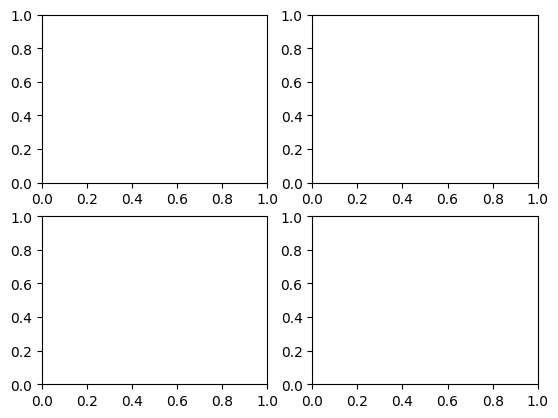

In [8]:




# Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = X_final[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

# Part 1

*Everyone should do this task.*

For the first part, use the large cats and dogs dataset in order to investigate the effects of varying the sample size (n) on the method.

Use at least 4 classifiers and make sure they span a spectrum from rigid to flexible. 

Compare the Performance: Measure the performance in each method as you decrease the sample size. Also compare the performance across methods.
You should use at least 2 performance metrics, e.g. accuracy, log-loss/cross-entropy, Brier score  ($\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K (\hat{p}_{ik}-y_{ik})^2$, where $y_{ik}=1$ when observation $i$ belongs to class k, and 0 otherwise), balanced accuracy, F1-macro, etc. The first 3 are more commonly used to compare models through repeated data splits because they mesh well with testing procedures. 

WE WILL TALK ABOUT THE FOLLOWING IN CLASS NEXT WEEK: I recommend you use rank-based tests to compare the models. That is, for each data split, obtain the ranks for all the models. Use the Friedman test to determine if there are any significant differences between model performance. If there is, perform all pairwise tests between models and adjust using the Holm procedure. Now you can either visualize these p-values in a M-by-M heat map (M models) or in a table with equivalent rank groups (e.g. Model 1, Model 3 > Model 2 > Model 4, Model 5). In Python, the \verbatim{scikit_posthocs} package has some of this implemented but you can also code from scratch. The Friedman-allpairsexact test is not available but you can use Nemenyi instead although it is more conservative.  A Bayesian variant allows for another way to create equivalent ranks through - this is implemented in a package called \verbatim{baycomp}. 

Be prepare to explain:
Which method was best and how did you evaluate this?
Did any method suprise you? 
What was your pipeline? 



In [2]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

X = images[4500:5500]
y = labels[4500:5500]

NameError: name 'images' is not defined

In [ ]:
# # GridSearch for CART function
# def grid_search_cart(X_train, y_train):

#     param_grid = {
#         "criterion": ["gini", "entropy", "log_loss"],
#         "splitter": ["best", "random"],
#         "max_features": ["sqrt", None],
#         "min_samples_leaf": np.arange(1, 20, 2),
#         "min_samples_split": np.arange(1, 20, 2)
#         }

#     CART = DecisionTreeClassifier()

#     # Grid search
#     CART_cv = GridSearchCV(
#         estimator=CART,
#         param_grid=param_grid,
#         cv=None,
#     )

#     CART_cv.fit(X_train, y_train)
    
#     print("Best Params: {}".format(CART_cv.best_params_))

def grid_search_cart(X_train, y_train):
    param_grid = {
        "criterion": ["gini", "entropy"], # Bantat lite för snabbhet
        "splitter": ["best"],
        "max_features": ["sqrt", None],
        "min_samples_leaf": [1, 5, 10, 15], # Färre men strategiska hopp
        "min_samples_split": [2, 6, 10, 14] # Startar på 2!
    }

    CART = DecisionTreeClassifier()

    CART_cv = GridSearchCV(
        estimator=CART,
        param_grid=param_grid,
        cv=5,            # Tydligt definierat
        n_jobs=-1,       # ANVÄND ALLA PROCESSORKÄRNOR
        verbose=3        # VISA VAD SOM HÄNDER
    )

    CART_cv.fit(X_train, y_train)
    print("Best Params: {}".format(CART_cv.best_params_))

In [ ]:
# # GridSearch for Random Forest

# def grid_search_rf(X_train, y_train):

#     param_grid = {
#         "n_estimators": [100, 200, 300],
#         "criterion": ["gini", "entropy", "log_loss"],
#         "max_features": ["sqrt", None, 1500],
#         "min_samples_leaf": np.arange(1, 20, 10),
#         "min_samples_split": np.arange(1, 20, 10)
#         }

#     RF = RandomForestClassifier(n_jobs=-1)

#     # Grid search
#     RF_cv = GridSearchCV(
#         estimator=RF,
#         param_grid=param_grid,
#         cv=None,
#         n_jobs=-1
#     )

#     RF_cv.fit(X_train, y_train)
    
#     print("Best Params: {}".format(RF_cv.best_params_))

def grid_search_rf(X_train, y_train):
    param_grid = {
        "n_estimators": [100, 200],              # 300 träd tar lång tid i onödan under grid search
        "criterion": ["gini", "entropy"],
        "max_features": ["sqrt", "log2"],         # Bort med 1500 och None om du vill ha fart
        "min_samples_leaf": [1, 10],
        "min_samples_split": [2, 10]              # Starta på 2!
    }

    # TA BORT n_jobs=-1 härifrån!
    RF = RandomForestClassifier() 

    # Grid search
    RF_cv = GridSearchCV(
        estimator=RF,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,                                # Låt den ligga kvar HÄR
        verbose=3                                 # VIKTIGT: Lägg till denna för att se framsteg!
    )

    RF_cv.fit(X_train, y_train)
    print("Best Params: {}".format(RF_cv.best_params_))

In [ ]:
# # GridSearch for Linear SVM

# def grid_search_svm(X_train, y_train):

#     param_grid = {
#         "C": [0.1, 1, 10],
#         "kernel": ["polynomial", "rbf"],
#         "gamma": ["scale", "auto"]
#         }

#     SVM = SVC()

#     # Grid search
#     SVM_cv = GridSearchCV(
#         estimator=SVM,
#         param_grid=param_grid,
#         cv=None,
#         n_jobs=-1
#     )

#     SVM_cv.fit(X_train, y_train)
    
#     print("Best Params: {}".format(SVM_cv.best_params_))


from sklearn.svm import SVC

def grid_search_svm(X_train, y_train):
    param_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["poly", "rbf"], # Ändrat från "polynomial" till "poly"
        "gamma": ["scale", "auto"]
    }

    # max_iter=10000 förhindrar att SVM fastnar för evigt på stor data
    SVM = SVC(max_iter=10000) 

    SVM_cv = GridSearchCV(
        estimator=SVM,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        verbose=3 # VIKTIGT för att se om den fastnar!
    )

    SVM_cv.fit(X_train, y_train)
    print("Best Params: {}".format(SVM_cv.best_params_))

In [ ]:
# # GridSearch for Logistic Regression
# def grid_search_logreg(X_train, y_train):

#     param_grid = {
#         "C": np.logspace(-3, 1, 30),
#         "l1_ratio": [0, 1],
#         "solver": ["liblinear"]
#         }

#     LOGREG = LogisticRegression()

#     # Grid search
#     LOGREG_cv = GridSearchCV(
#         estimator=LOGREG,
#         param_grid=param_grid,
#         cv=None
#     )

#     LOGREG_cv.fit(X_train, y_train)
    
#     print("Best Params: {}".format(LOGREG_cv.best_params_))

def grid_search_logreg(X_train, y_train):
    param_grid = {
        "C": np.logspace(-3, 1, 10),       # Minskat till 10 värden (räcker oftast gott och väl för grid search)
        "penalty": ["elasticnet"],         # Måste specificeras för att l1_ratio ska göra något
        "l1_ratio": [0, 0.5, 1],           # 0 = ren L2, 1 = ren L1, 0.5 = mix
        "solver": ["saga"]                 # SAGA krävs för elasticnet och är bra på stor data
    }

    # Öka max_iter till 2000 så att saga hinner konvergera (hitta bästa svaret)
    LOGREG = LogisticRegression(max_iter=2000)

    # Grid search
    LOGREG_cv = GridSearchCV(
        estimator=LOGREG,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,                         # Kör på alla kärnor!
        verbose=3                          # Visa framsteg
    )

    LOGREG_cv.fit(X_train, y_train)
    print("Best Params: {}".format(LOGREG_cv.best_params_))

In [ ]:
R = 1
K = 2

for r in range(R):
    # TODO: shuffle data before KFold
    kf = KFold(n_splits=K, shuffle=True, random_state=42)
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        grid_search_cart(X_train, y_train)
        grid_search_rf(X_train, y_train)
        grid_search_logreg(X_train, y_train)
        grid_search_svm(X_train, y_train)

## Part 2 - Themes
You will be allocated one of the three themes and should perform ***all*** tasks as described in this theme.

### Theme 1 - Imbalance
Use the Cats and Dogs dataset.

Investigate the effects of imbalance on PART 1 - where you create the imbalance. Try with different train, calibration and test sizes. 

Does the model ranking change?

### Theme 2 - Conformal Prediction
Use the MNIST data set.

Select 3 classifiers. Perform conformal prediction. Do you observe similar conformal predictions between the methods? Summarize the conformal predictions. Are certain classes more often to be lumped together in the same set of predictions and does it depend on the classifier used? 

Try with different train, calibration and test sizes. 

### Theme 3 - Mislabeling

Create a mislabeled data set from the digits data by randomly changing the labels for some of the observations. *Note, you should only create mislabels for your training data - the test data should be clean.*

Redo Part 1 in this setting.

Which methods handle the mislabeling OK? Which methods struggle? How does sample size affect this?

You should explore at least 3 levels of mislabeling (some modest, some more severe and some really severe cases), i.e. proportion of mislabeled data. *Please note that your test data should be "clean", i.e. without mislabeling*. For each simulation run, make sure you create a clean and separate data set to estimate prediction performance.

Do the above on 3 levels of data (full data, medium data, small data).